In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Normal Bandits

In [95]:
window_bandits_120 = pd.read_csv('outputs/longer_horizon_output/bandit_window_summaries.csv')

In [96]:
algo_vs_reward_df = window_bandits_120.groupby(['algorithm', 'episode', 'seed'], as_index=False).agg(reward=('window_cumulative_reward', 'sum')).groupby(['algorithm', 'episode'], as_index=False).agg(reward=('reward', 'mean')).copy()
algo_vs_reward_df

,algorithm,episode,reward
0,epsilon_greedy,0,-290.972469
1,epsilon_greedy,1,-398.372562
2,epsilon_greedy,2,-491.375879
3,epsilon_greedy,3,-393.662705
4,epsilon_greedy,4,-381.242528
...,...,...,...
115,ucb1,25,-253.682273
116,ucb1,26,-253.682273
117,ucb1,27,-253.682273
118,ucb1,28,-253.682273


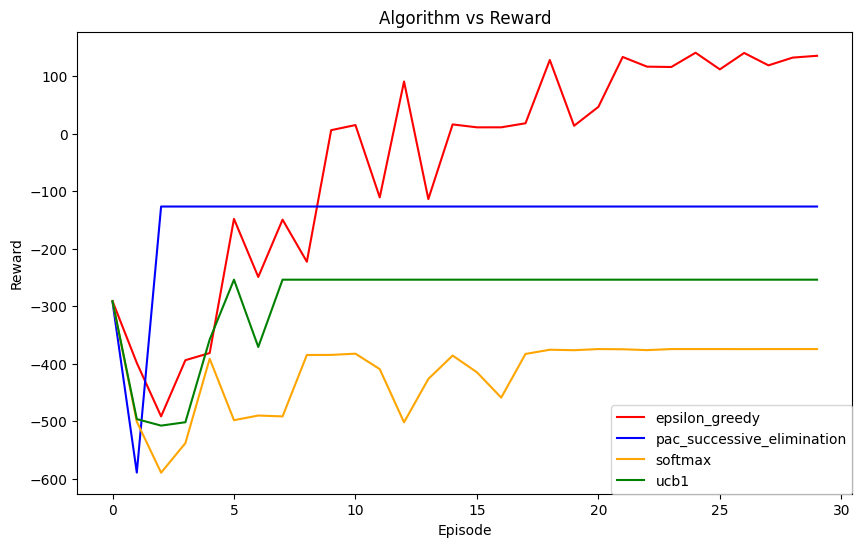

In [97]:
#filtered_data = filtered_data.reset_index()
plt.figure(figsize=(10,6))

for algo, color in zip(algo_vs_reward_df['algorithm'].unique().tolist(), ['red', 'blue', 'orange', 'green']):
    slice_df = algo_vs_reward_df[algo_vs_reward_df['algorithm']==algo]
    plt.plot(slice_df['episode'], slice_df['reward'], label=algo, color=color)

plt.title('Algorithm vs Reward')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend(loc="lower right", borderaxespad=0)

plt.show()

In [12]:
import matplotlib.cm as cm
def get_high_contrast_colors(num_lines):
    """Returns a list of high-contrast hex or RGBA colors based on the line count."""
    if num_lines <= 10:
        # 'tab10' is Matplotlib's default high-contrast qualitative map
        return [cm.tab10(i) for i in range(num_lines)]
    elif num_lines <= 20:
        # 'tab20' handles up to 20 lines with distinct paired shades
        return [cm.tab20(i) for i in range(num_lines)]
    else:
        # Fallback for > 20 lines: programmatically sample across a continuous high-contrast spectrum
        # 'turbo' or 'jet' offer the highest mathematical contrast across large quantities
        return [cm.turbo(i) for i in np.linspace(0, 1, num_lines)]

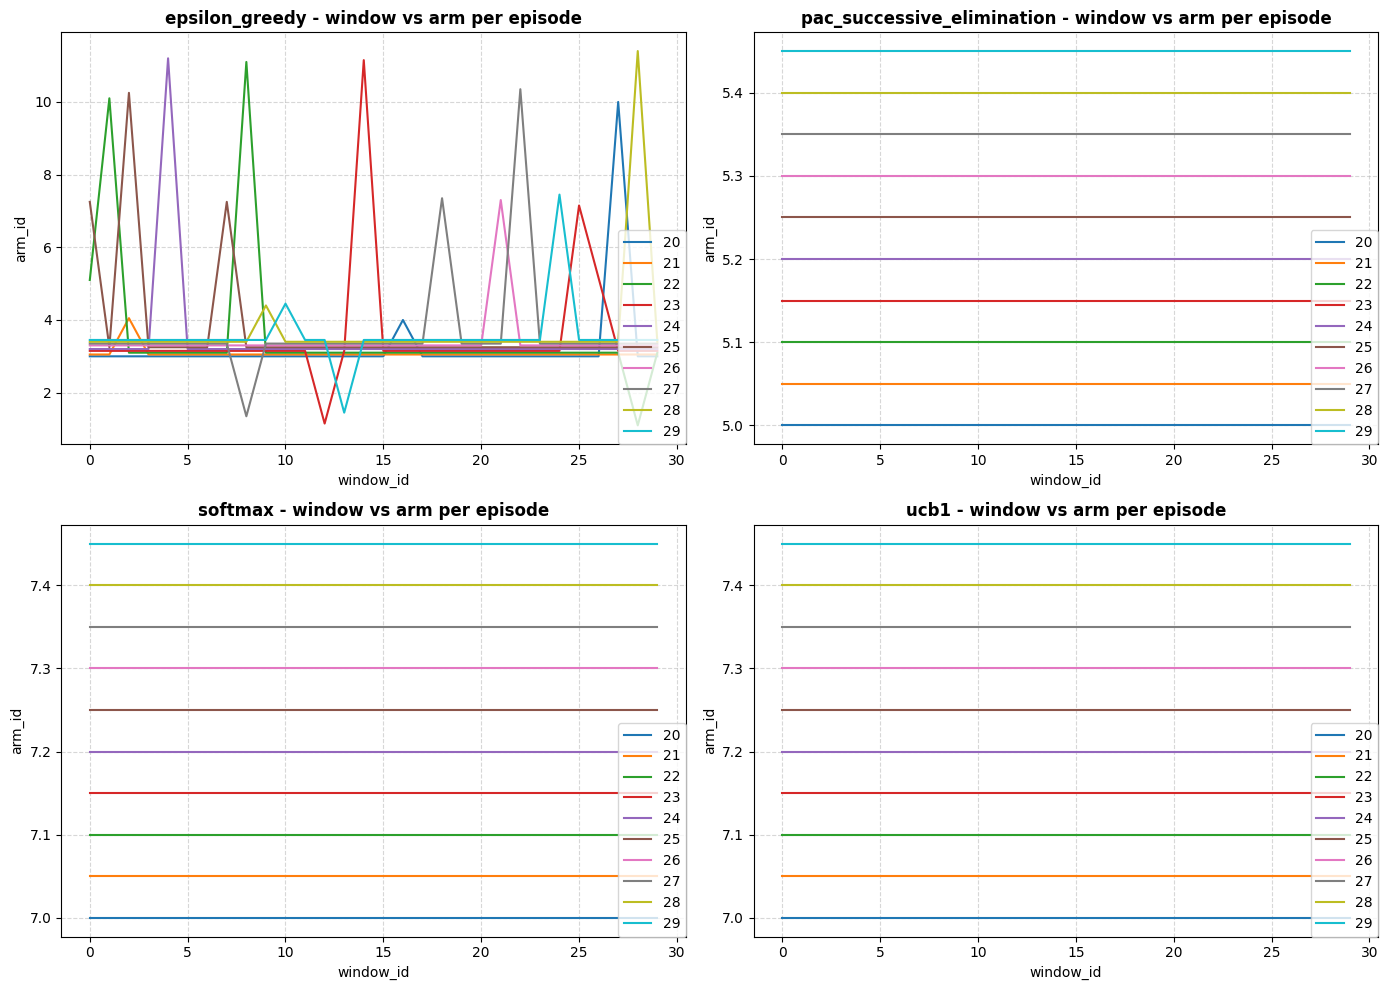

In [100]:
'''
pac_vs_arm_df = window_bandits_120[(window_bandits_120['algorithm']=='pac_successive_elimination') & (window_bandits_120['seed']==0)][['algorithm', 'window_index', 'episode', 'arm_id']].copy()
softmax_vs_arm_df = window_bandits_120[(window_bandits_120['algorithm']=='softmax') & (window_bandits_120['seed']==0)][['algorithm', 'window_index', 'episode', 'arm_id']].copy()
ucb1_vs_arm_df = window_bandits_120[(window_bandits_120['algorithm']=='ucb1') & (window_bandits_120['seed']==0)][['algorithm', 'window_index', 'episode', 'arm_id']].copy()
epsilon_greedy_vs_arm_df = window_bandits_120[(window_bandits_120['algorithm']=='epsilon_greedy') & (window_bandits_120['seed']==0)][['algorithm', 'window_index', 'episode', 'arm_id']].copy()
'''

list_of_algos = algo_vs_reward_df['algorithm'].unique().tolist()
algo_vs_arm_dfs = [window_bandits_120[(window_bandits_120['algorithm']==algo) & (window_bandits_120['seed']==0)][['algorithm', 'window_index', 'episode', 'arm_id']].copy() for algo in list_of_algos]
titles = [f'{algo} - window vs arm per episode' for algo in list_of_algos]
episode_sample_size = 8

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes_flat = axes.flatten()

for indx, (ax, episode_df, title) in enumerate(zip(axes_flat, algo_vs_arm_dfs, titles)):
    episodes = episode_df['episode'].unique().tolist()[20:30]
    colors = get_high_contrast_colors(len(episodes))

    for indx, episode in enumerate(episodes):
        slice_df = episode_df[episode_df['episode']==episode]
        offset = indx*0.05
        ax.plot(slice_df['window_index'], slice_df['arm_id']+offset, label=episode, color=colors[indx])

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('window_id')
    ax.set_ylabel('arm_id')
    ax.legend(loc="lower right", borderaxespad=0)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Contextual bandits

In [9]:
window_contextual_120 = pd.read_csv('outputs/contextual_bandits_run/contextual_window_summaries.csv')

In [10]:
algo_vs_reward_df = window_contextual_120.groupby(['algorithm', 'episode', 'seed'], as_index=False).agg(reward=('window_cumulative_reward', 'sum')).groupby(['algorithm', 'episode'], as_index=False).agg(reward=('reward', 'mean')).copy()

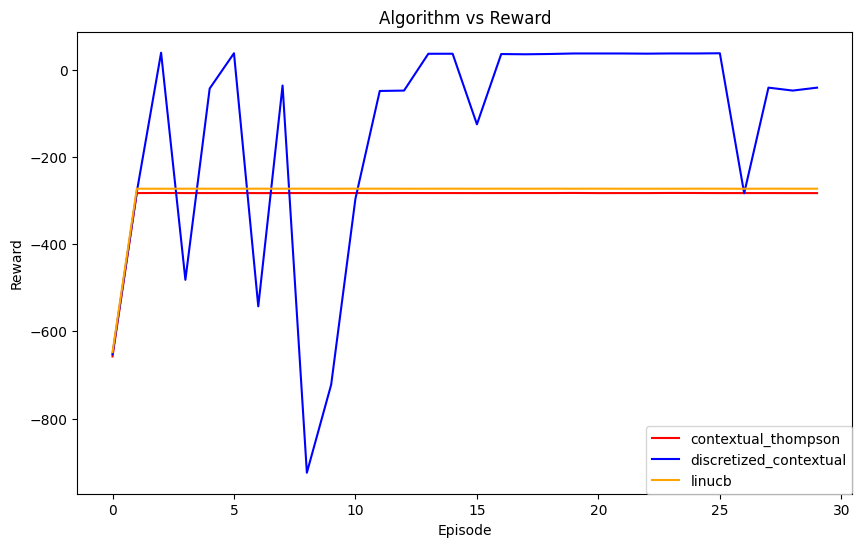

In [11]:
#filtered_data = filtered_data.reset_index()
plt.figure(figsize=(10,6))
off_set = 5
for idx, (algo, color) in enumerate(zip(algo_vs_reward_df['algorithm'].unique().tolist(), ['red', 'blue', 'orange', 'green'])):
    slice_df = algo_vs_reward_df[algo_vs_reward_df['algorithm']==algo]
    plt.plot(slice_df['episode'], slice_df['reward']+idx*off_set, label=algo, color=color)

plt.title('Algorithm vs Reward')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend(loc="lower right", borderaxespad=0)

plt.show()

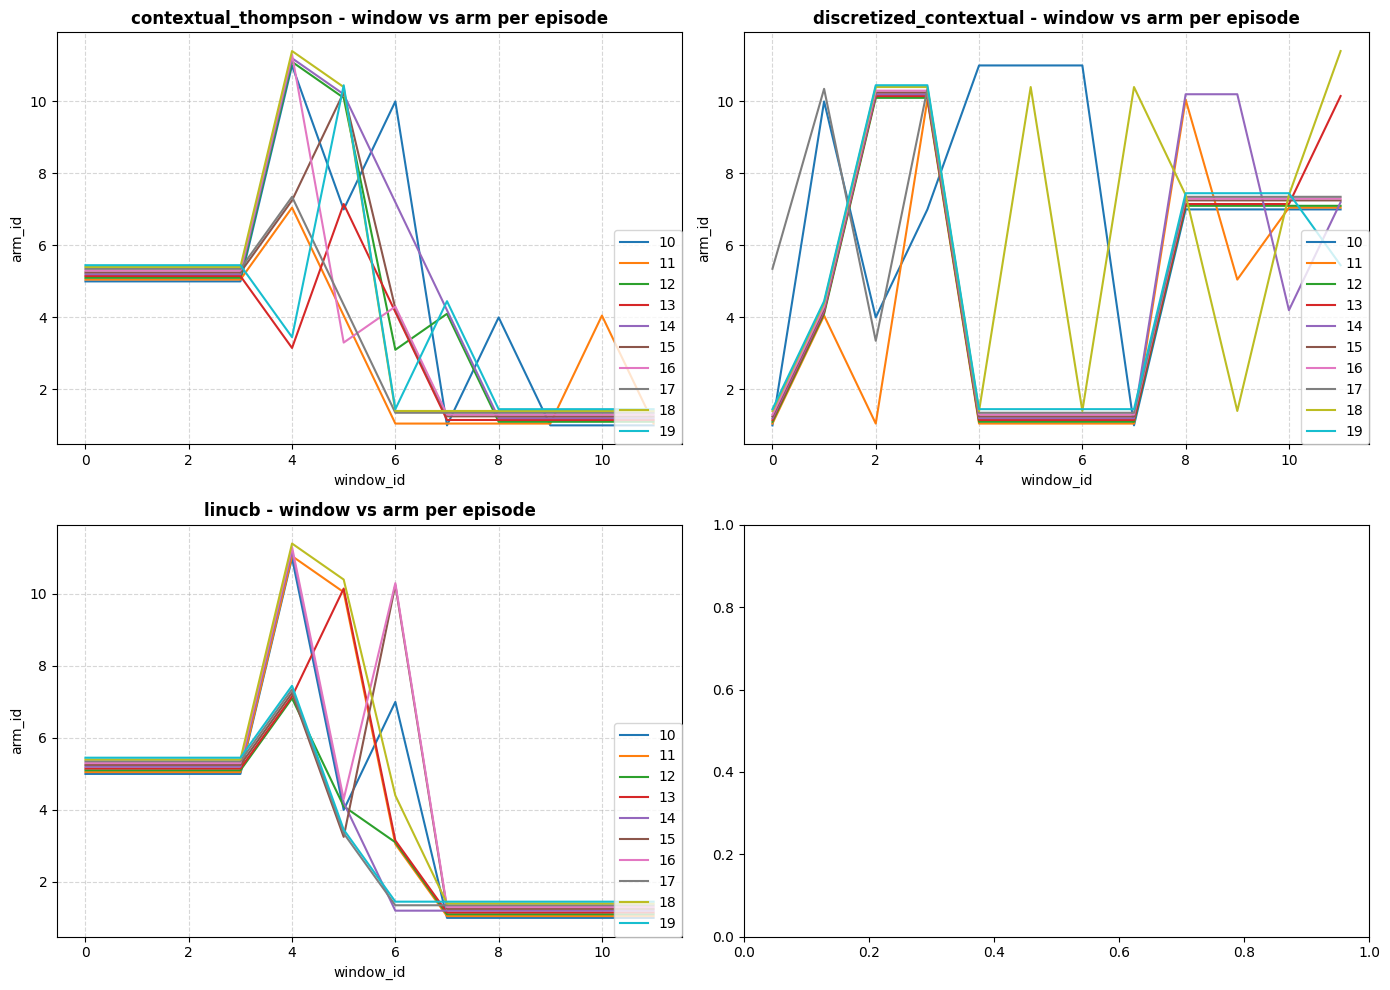

In [16]:
list_of_algos = algo_vs_reward_df['algorithm'].unique().tolist()
algo_vs_arm_dfs = [window_contextual_120[(window_contextual_120['algorithm']==algo) & (window_contextual_120['seed']==0)][['algorithm', 'window_index', 'episode', 'arm_id']].copy() for algo in list_of_algos]
titles = [f'{algo} - window vs arm per episode' for algo in list_of_algos]
episode_sample_size = 8

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes_flat = axes.flatten()

for indx, (ax, episode_df, title) in enumerate(zip(axes_flat, algo_vs_arm_dfs, titles)):
    episodes = episode_df['episode'].unique().tolist()[10:20]
    colors = get_high_contrast_colors(len(episodes))

    for indx, episode in enumerate(episodes):
        slice_df = episode_df[episode_df['episode']==episode]
        offset = indx*0.05
        ax.plot(slice_df['window_index'], slice_df['arm_id']+offset, label=episode, color=colors[indx])

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('window_id')
    ax.set_ylabel('arm_id')
    ax.legend(loc="lower right", borderaxespad=0)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
